
# Convolutional Neural Networks (CNNs)

## Why not MLPs?

If you want to recognize a face using a standard Multi-Layer Perceptron (MLP), you have to flatten the image into a long line of pixels.

-   **Problem 1**: You lose spatial structure (a nose is defined by being **above** a mouth, not just by pixel values).
-   **Problem 2**: Too many weights. A $1000 \times 1000$ image has 1 million pixels. Connecting that to just 100 neurons requires **100 million weights**.

**Convolutional Neural Networks (CNNs)** solve this by looking at local "patches" of the image rather than the whole thing at once.

## The Convolution Layer (`Conv2d`)

This is the heart of the CNN. Instead of learning a weight for every pixel, we learn small **Filters** (or Kernels).

-   A filter might be $3 \times 3$ pixels.
-   It slides (convolves) over the image, calculating the dot product at each position.
-   This creates a **Feature Map** representing where that pattern appeared.

### Visualizing the Convolution

Let's see how a simple edge-detecting filter works on an image.

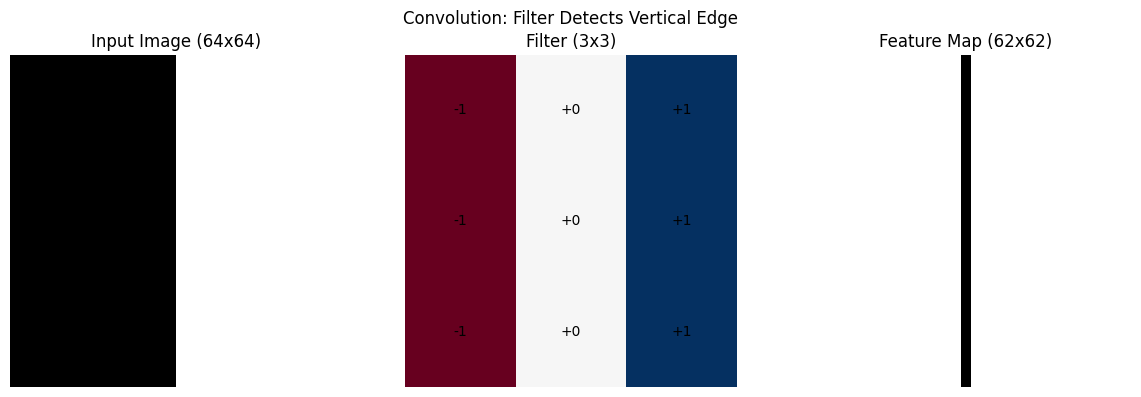

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Create a simple 64x64 image with a vertical edge
image = np.zeros((64, 64))
image[:, 32:] = 1  # Right half is white

# Define a vertical edge detector (Sobel-like)
filter_v = np.array([[-1, 0, 1],
                     [-1, 0, 1],
                     [-1, 0, 1]])

# Convolve
output = convolve2d(image, filter_v, mode='valid')

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Input Image (64x64)")
axes[0].axis('off')

axes[1].imshow(filter_v, cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title("Filter (3x3)")
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{filter_v[i,j]:+d}', ha='center', va='center')
axes[1].axis('off')

axes[2].imshow(output, cmap='gray')
axes[2].set_title(f"Feature Map ({output.shape[0]}x{output.shape[1]})")
axes[2].axis('off')

plt.suptitle("Convolution: Filter Detects Vertical Edge")
plt.tight_layout()
plt.show()

**Observation**: The filter "fires" (produces high values) where it detects a vertical edge in the image.

## Controlling Dimensions: Padding & Stride

As the filter slides, the image shrinks.

-   **Valid Convolution**: No padding. The output shrinks (e.g., $5 \times 5 \to 3 \times 3$).
-   **Padding**: Adding zeros around the border to maintain the size ($5 \times 5 \to 5 \times 5$).
-   **Stride**: How many pixels we jump. Stride=2 usually reduces size by about half (downsampling).

## Pooling Layers

Pooling progressively reduces the spatial size (and parameters) to control overfitting and computational cost.

| Type                       | Operation           | Use Case                                       |
|-------------------------- |------------------- |---------------------------------------------- |
| **Max Pooling**            | Takes largest value | Feature detection ("Is there an edge here?")   |
| **Average Pooling**        | Takes mean value    | Smoother downsampling, less aggressive         |
| **Global Average Pooling** | Mean of entire map  | Replaces Fully Connected layers in modern CNNs |

-   **Max Pooling (`MaxPool2d`)**: The most common. Keeps the strongest activation in each patch.
-   **Average Pooling (`AvgPool2d`)**: Smoother, sometimes used instead of max pooling.
-   **Global Average Pooling (`AdaptiveAvgPool2d(1)`)**: Reduces entire feature map to a single value per channel. Used in ResNet/EfficientNet to avoid massive Linear layers.

## Common Architectures

Modern Deep Learning is built on famous architectures:

-   **VGG (2014)**: Simplicity. Stacks many small $3 \times 3$ filters. Very deep, very heavy.
-   **ResNet (2015)**: Introduced **Skip Connections** (Residuals). Allows training networks with 100+ layers by letting gradients "skip" layers to avoid vanishing.

### The Skip Connection (Residual Block)

The key innovation in ResNet is simple: add the input back to the output.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    """A basic building block of ResNet."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x  # Save the input (the "skip")

        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))

        x = x + residual  # Add the original input back!
        return F.relu(x)

# Test it
block = ResidualBlock(channels=64)
test_input = torch.randn(1, 64, 28, 28)
output = block(test_input)
print(f"Input: {test_input.shape} -> Output: {output.shape}")

Input: torch.Size([1, 64, 28, 28]) -> Output: torch.Size([1, 64, 28, 28])


**Key Insight**: The `x + residual` allows gradients to flow directly through the addition, bypassing the convolutions if needed. This prevents vanishing gradients in very deep networks.

## Practical Demonstration: Building a CNN in PyTorch

We will build a simple CNN to classify digits (`MNIST`) or clothing (`FashionMNIST`). We focus on tracking the **Tensor Shapes**.

### The Anatomy of a CNN

In [3]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1: Feature Extraction
        # Input: (1, 28, 28) -> Output: (32, 28, 28)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        # Input: (32, 28, 28) -> Output: (32, 14, 14)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: Deeper Features
        # Input: (32, 14, 14) -> Output: (64, 14, 14)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        # Input: (64, 14, 14) -> Output: (64, 7, 7)
        self.pool2 = nn.MaxPool2d(2)

        # Block 3: Classification (The Flattening)
        self.flatten = nn.Flatten()
        # Why 64 * 7 * 7? Because that's the shape coming out of pool2
        self.fc1 = nn.Linear(64 * 7 * 7, 10) # 10 classes

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc1(x)
        return x

model = SimpleCNN()
# Print shape check with dummy data
dummy_input = torch.randn(1, 1, 28, 28) # Batch=1, Channel=1, H=28, W=28
output = model(dummy_input)
print(f"Output Shape: {output.shape} (Should be [1, 10])")

Output Shape: torch.Size([1, 10]) (Should be [1, 10])


### Training on FashionMNIST

Let's train our CNN on real data.

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim

# 1. Load FashionMNIST
transform = transforms.ToTensor()
train_data = datasets.FashionMNIST(root='./data', train=True,
                                    download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

# 2. Setup
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Training Loop (3 epochs for demo)
for epoch in range(3):
    running_loss = 0.0
    for images, labels in train_loader:
        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

print("Training Complete!")

Epoch 1, Loss: 0.4603
Epoch 2, Loss: 0.3092
Epoch 3, Loss: 0.2708
Training Complete!


### Visualizing CNN Responses

After training, we can inspect how the first convolutional layer responds to an input image.

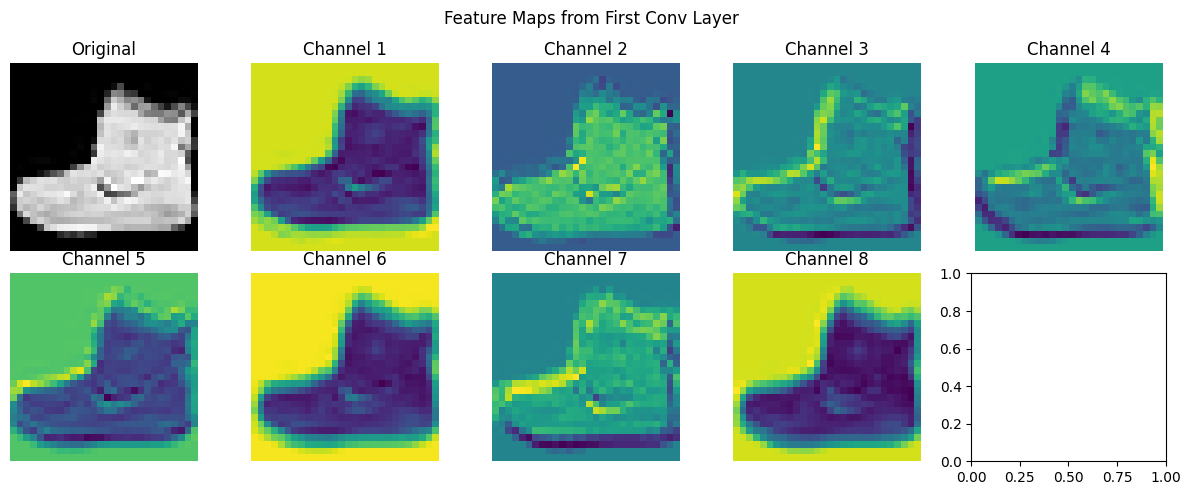

In [5]:
import matplotlib.pyplot as plt

# Get a sample image
sample_img, label = train_data[0]

# Hook to capture activations
activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Register hook on first conv layer
handle = model.conv1.register_forward_hook(get_activation('conv1'))

# Forward pass
with torch.no_grad():
    _ = model(sample_img.unsqueeze(0))
handle.remove()

# Plot first 8 feature maps
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes[0, 0].imshow(sample_img.squeeze(), cmap='gray')
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flat[1:9]):
    ax.imshow(activations['conv1'][0, i].numpy(), cmap='viridis')
    ax.set_title(f"Channel {i+1}")
    ax.axis('off')

plt.suptitle("Feature Maps from First Conv Layer")
plt.tight_layout()
plt.show()

**Observation**: Each filter detects different patterns (edges, textures, shapes).

### Using Pretrained Models (ResNet)

In practice, we rarely build from scratch. We use **Transfer Learning** with models like *ResNet*. `torchvision` makes this easy. Typical workflow: replace the classifier head, decide whether to freeze early layers, and ensure inputs use the preprocessing expected by the pretrained weights.

In [6]:
from torchvision import models

# Load a ResNet18
# weights='DEFAULT' loads weights trained on ImageNet (1000 classes)
resnet = models.resnet18(weights='DEFAULT')

print("Original Output Layer:", resnet.fc)

# Modify for our task (e.g., 2 classes instead of 1000)
# in_features allows us to keep the connection to the previous layer
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

print("New Output Layer:     ", resnet.fc)

Original Output Layer: Linear(in_features=512, out_features=1000, bias=True)
New Output Layer:      Linear(in_features=512, out_features=2, bias=True)


## Exercises

### Calculating Shapes

Understanding shape changes is crucial. Given an input of $(1, 32, 32)$:

1.  Apply `Conv2d(1, 16, kernel_size=5, stride=1, padding=0)`. What is the new size? **Formula**: $O = \frac{I - K + 2P}{S} + 1$
2.  Apply `MaxPool2d(2)`. What is the new size?

In [7]:
# Let PyTorch calculate it for you to verify your math
layer_conv = nn.Conv2d(1, 16, kernel_size=5, padding=0)
layer_pool = nn.MaxPool2d(2)

x = torch.randn(1, 1, 32, 32)
out_conv = layer_conv(x)
out_pool = layer_pool(out_conv)

print(f"After Conv: {out_conv.shape}")
print(f"After Pool: {out_pool.shape}")

After Conv: torch.Size([1, 16, 28, 28])
After Pool: torch.Size([1, 16, 14, 14])


### Implementing a VGG Block

A "VGG Block" consists of: `Conv3x3` -> `ReLU` -> `Conv3x3` -> `ReLU` -> `MaxPool` Implement this as a `nn.Sequential` module.

In [8]:
def vgg_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

block = vgg_block(3, 64) # RGB Input -> 64 Filters
print(block)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


## Summary

1.  **Conv Layers**: Look for local patterns (edges, textures). Use `padding` to keep size, `stride` to shrink.
2.  **Pooling**: Summarizes features and reduces size.
3.  **Shapes**: Always track your $H \times W$ dimensions. If they reach 0 or mismatch the Linear layer, the code crashes.
4.  **ResNet**: A widely used and strong baseline family for image tasks.